In [1]:
import numpy as np
import pandas as pd
from variable_leverage_env_1 import agentDLVEnvV2
import os
import shutil
import random
from ReLuExtractor import ReLUFeatureExtractor
from stable_baselines3 import PPO
import torch.nn as nn
from utils import plot_episode_history_v2, plot_metrics_v2, plot
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.callbacks import CallbackList

In [2]:
df = pd.read_csv('island_data.csv')
timestamp = df['timestamp'].values
nav = df['nav'].values
nect_price = pd.read_csv('nect_honey_price.csv')['price'].values
vol_token_price = pd.read_csv('wbtc_honey_price.csv')['price'].values
volatile_part = df['wbtc_frac'].values
len(volatile_part)

10000

In [3]:
def naiveAgent(obs, min_cr=1.2, eps=1e-9):
    leverage = obs[0]
    bottom_leverage = obs[1]
    cr = 1/obs[2]

    if bottom_leverage <= 0.8:
        return 4
    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        return 1
    else:
        return 0

In [4]:
def make_env(i, b_l, t_l):
    def _init():
        env = agentDLVEnvV2(
            nect_honey_price = nect_price,
            nav_in_honey = nav,
            vol_part = volatile_part,
            vol_token_honey_price = vol_token_price,
            is_training = True,
            is_mixed = True,
            top_leverage = t_l,
            bottom_leverage = b_l
        )
        return Monitor(env)
    return _init

In [5]:
vec_env = DummyVecEnv([make_env(0, 2.5, 2.9)])

policy_kwargs = dict(
        features_extractor_class=ReLUFeatureExtractor,
        features_extractor_kwargs=dict(features_dim=128),
        activation_fn=nn.ReLU,
        net_arch=dict(
            pi=[128, 128, 128],
            vf=[128, 128, 128]
        )  
    )

model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    n_steps=1024,
    policy_kwargs=policy_kwargs,
    vf_coef = 2.1,
    clip_range = 0.15,
    clip_range_vf = 0.15,
    ent_coef = 0.03,
    device = "cuda"   
)

model.set_parameters("variable_leverage_model_ppo/ppo_model_final.zip")

action scale 0.9
primordial penalty 0.9
loss scale 0.5
liquidation penalty 5
risk coef 0
boundary reward scale 1
Using cuda device


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [6]:
eval_env= agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = True,
    top_leverage=2.7,
    bottom_leverage=2.4
)

action scale 0.9
primordial penalty 0.9
loss scale 0.5
liquidation penalty 5
risk coef 0
boundary reward scale 1


action scale 0.9
primordial penalty 0.9
loss scale 0.5
liquidation penalty 5
risk coef 0
boundary reward scale 1
5376
6675


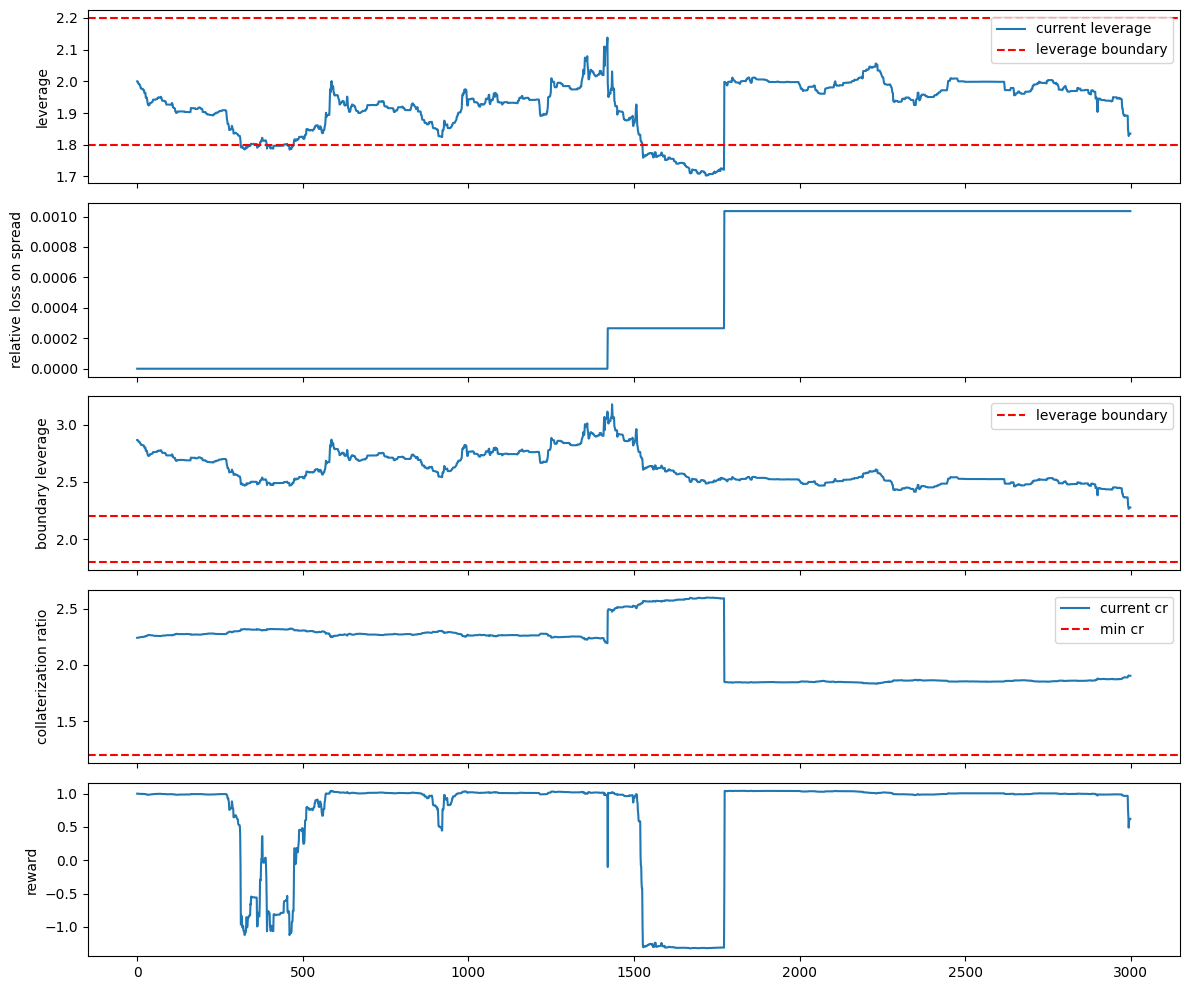

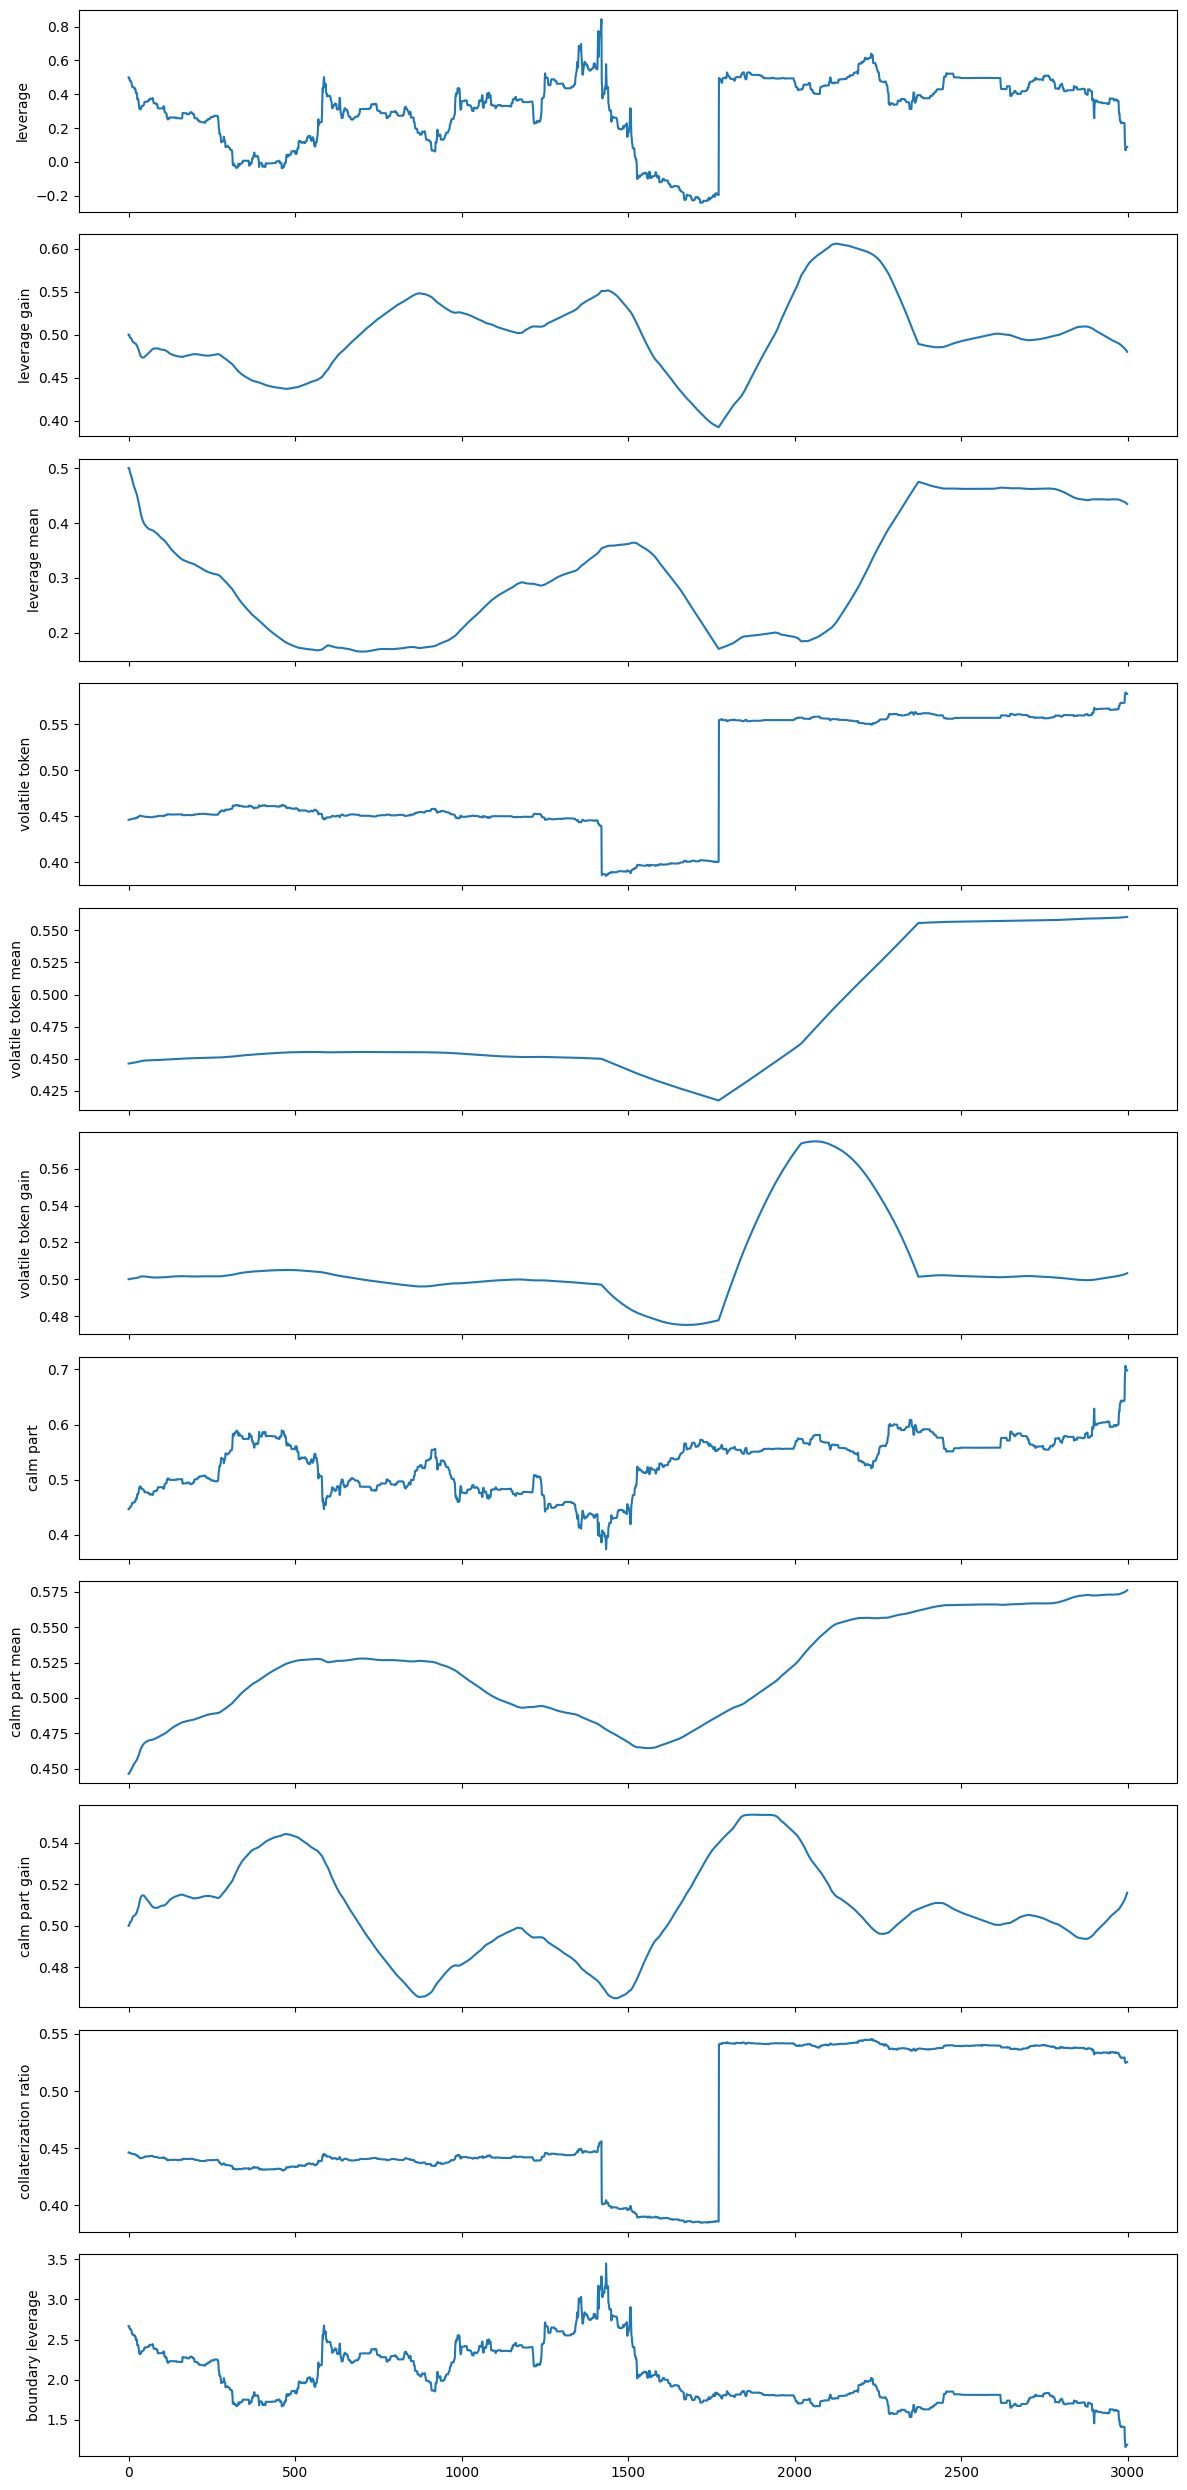

In [7]:
eval_env = DummyVecEnv([lambda: agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = True,
    top_leverage=2.2,
    bottom_leverage=1.8
)])

done = False
obs = eval_env.reset()  
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = eval_env.step(action)
    done = dones[0]
    info = infos[0]

history = info['episode_history']
history_metrics = info['episode_metrics']

t_l = info['top leverage']
b_l = info['bottom leverage']
economic_metrics = info['episode_economics']
plot_episode_history_v2(history, t_l, b_l)
plot_metrics_v2(history_metrics)

ValueError: x and y must have same first dimension, but have shapes (10000,) and (3000,)

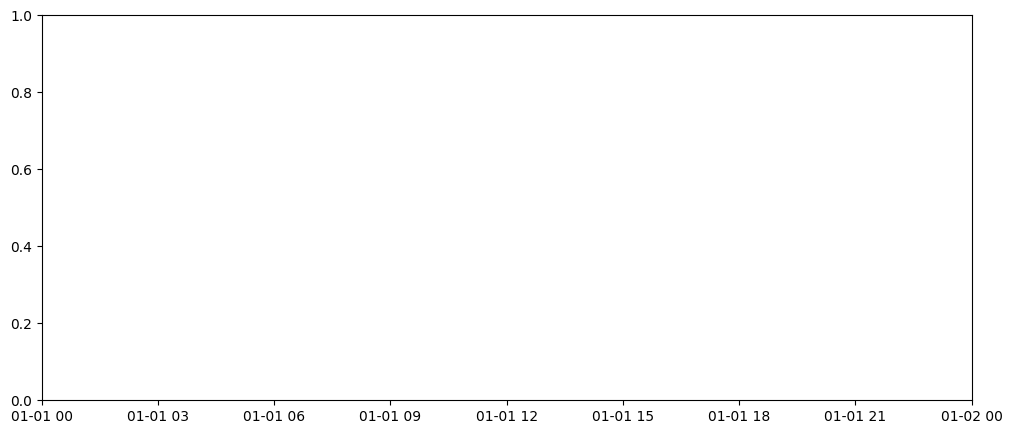

In [8]:
date = timestamp.astype("datetime64[s]")

plot(
    date,
    economic_metrics['leverage'],
    'date',
    'leverage',
    'Mechanical agent leverage'
)

plot(
    date,
    economic_metrics['PNL'],
    'date',
    'PNL',
    'Mechanical agent PNL'
)

plot(
    date,
    np.array(economic_metrics['return'])*100,
    'date',
    'return, %',
    'Mechanical agent return'
)

plot(
    date,
    economic_metrics['collaterization ratio'],
    'date',
    'collaterization ratio',
    'Mechanical agent CR'
)

plot(
    date,
    economic_metrics['vol token amount'],
    'date',
    'WBTC amount',
    'Mechanical agent WBTC amount'
)

plot(
    date,
    economic_metrics['nect debt'],
    'date',
    'NECT debt',
    'Mechanical agent debt'
)

plot(
    date,
    economic_metrics['vol token price'],
    'date',
    'price (in honey)',
    'WBTC price'
)

plot(
    date,
    economic_metrics['nect price'],
    'date',
    'price (in honey)',
    'NECT price'
)

plot(
    date,
    economic_metrics['nav'],
    'date',
    'nav (in honey)',
    'WBTC-HONEY island token nav'
)

plot(
    date,
    np.array(economic_metrics['calm part'])*100,
    'date',
    'calm part, %',
    'WBTC-HONEY island token calm part'
)